In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import chess
from stockfish import Stockfish

In [2]:
DB_PATH = "F:/databases/chess.db"
STOCKFISH_PATH = r"C:\Users\maxol\chess\engines\stockfish\stockfish-windows-x86-64-avx2"
stockfish = Stockfish(STOCKFISH_PATH)

cnxn = sqlite3.connect(DB_PATH)
cursor = cnxn.cursor()

In [23]:
search_df = pd.read_sql_query('SELECT * FROM searches', cnxn)
depth_df = pd.read_sql_query('SELECT * FROM searches_by_depth', cnxn)
game_df = pd.read_sql_query('SELECT * FROM games', cnxn)

search_df['game_id'] = search_df['game_id'].astype('Int64')

print(len(search_df), len(depth_df))
display(search_df.tail())
display(depth_df.head())
display(game_df.head())

3012 14827


,id,game_id,sts_id,fen,ply,time_ms,eval,depth,move,principal_variation,...,tt_fill,fail_highs,fail_lows,fail_high_first,fail_high_late,fail_high_researches,fail_low_researches,see_prunes,delta_prunes,integestion_timestamp_utc
3007,3008,7,NaN,8/3P4/5n2/5k2/6pK/7p/8/6q1 b - - 0 78,156,None,100000,1,g1e1,None,...,None,0,0,None,None,None,None,None,None,2026-01-19 22:23:57
3008,3009,10,NaN,8/8/8/8/4n3/5r2/K1pk4/8 w - - 0 79,157,None,-99997,7,a2b2,None,...,None,13151,1240,None,None,None,None,None,None,2026-01-19 22:23:57
3009,3010,9,NaN,8/8/8/8/4n3/5r2/1Kpk4/8 b - - 1 79,158,None,99998,5,c2c1q,None,...,None,1497,1048,None,None,None,None,None,None,2026-01-19 22:23:57
3010,3011,10,NaN,8/8/8/8/4n3/5r2/1K1k4/2q5 w - - 0 80,159,None,-99999,5,b2a2,None,...,None,42,27,None,None,None,None,None,None,2026-01-19 22:23:57
3011,3012,9,NaN,8/8/8/8/4n3/5r2/K2k4/2q5 b - - 1 80,160,None,100000,1,f3a3,None,...,None,0,0,None,None,None,None,None,None,2026-01-19 22:23:57


,search_id,depth,time_ms,eval,move,nodes,q_nodes,tt_stores,tt_hits,tt_fill,fail_highs,fail_lows,fail_high_first,fail_high_late,fail_high_researches,fail_low_researches,see_prunes,delta_prunes,integestion_timestamp_utc
0,1,1,0.1705,475,e4a8,157,40,0,0,0.0,1,0,0,0,0,0,0,0,2026-01-19 22:13:10
1,1,2,3.2248,403,e4a8,3025,397,4666,0,0.0,2107,1,0,0,0,0,0,0,2026-01-19 22:13:10
2,1,3,7.5940,471,e4a8,7368,1964,983,339,0.0,3153,816,0,0,0,0,0,0,2026-01-19 22:13:10
3,1,4,38.9765,438,e4a8,29935,4334,37,0,0.0,1002,0,0,0,0,0,0,0,2026-01-19 22:13:10
4,2,1,0.2355,62,d4f5,177,48,0,0,0.0,1,0,0,0,0,0,0,0,2026-01-19 22:13:10


,id,experiment_id,white_engine_id,black_engine_id,time_control,time_per_move,depth_per_move,result,termination,opening,start_fen,moves,run_time_s,integestion_timestamp_utc
0,1,3,1,1,None,None,None,3,None,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e5"", ""g1f3"", ""b8c6"", ""d2d4"", ""d7d5...",11.69840,2026-01-19 22:17:45
1,2,3,1,2,None,None,None,3,None,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e5"", ""g1f3"", ""b8c6"", ""d2d4"", ""d7d5...",NaN,2026-01-19 22:17:45
2,3,4,1,1,None,None,None,1,None,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e5"", ""g1f3"", ""b8c6"", ""d2d4"", ""e5d4...",8.00364,2026-01-19 22:23:26
3,4,4,1,2,None,None,None,1,None,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e5"", ""g1f3"", ""b8c6"", ""d2d4"", ""e5d4...",NaN,2026-01-19 22:23:26
4,5,4,1,1,None,None,None,3,None,None,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,"[""e2e4"", ""e7e5"", ""g1f3"", ""b8c6"", ""d2d4"", ""d7d5...",11.66350,2026-01-19 22:23:26


In [24]:
game_df['result'] = game_df['result'].map({'1':'win','3':'draw'})
search_df['game_result'] = search_df.merge(game_df[['id','result']], left_on=['game_id'], right_on=['id'], how='left')['result']
search_df

,id,game_id,sts_id,fen,ply,time_ms,eval,depth,move,principal_variation,...,fail_highs,fail_lows,fail_high_first,fail_high_late,fail_high_researches,fail_low_researches,see_prunes,delta_prunes,integestion_timestamp_utc,game_result
0,1,<NA>,1.0,r1bq1r1k/p1pnbpp1/1p2p3/6p1/3PB3/5N2/PPPQ1PPP/...,1,None,438,4,e4a8,None,...,9434,817,None,None,None,None,None,None,2026-01-19 22:13:10,NaN
1,2,<NA>,1.0,r1b2rk1/1p1nbppp/pq1p4/3B4/P2NP3/2N1p3/1PP3PP/...,1,None,75,4,d4f5,None,...,8807,872,None,None,None,None,None,None,2026-01-19 22:13:10,NaN
2,3,<NA>,1.0,r1q1k2r/1p1nbpp1/2p2np1/p1Pp4/3Pp3/P1N1P1P1/1P...,2,None,26,4,e8g8,None,...,7279,981,None,None,None,None,None,None,2026-01-19 22:13:10,NaN
3,4,<NA>,1.0,2rr3k/2qnbppp/p1n1p3/1p1pP3/3P1N2/1Q1BBP2/PP3P...,1,None,124,4,b3d1,None,...,8871,266,None,None,None,None,None,None,2026-01-19 22:13:10,NaN
4,5,<NA>,1.0,3q1r1k/1b3ppp/p1n5/1p1pPB2/2rP4/P6N/1P2Q1PP/R4...,1,None,-1,4,e2e3,None,...,7411,1034,None,None,None,None,None,None,2026-01-19 22:13:10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3007,3008,7,NaN,8/3P4/5n2/5k2/6pK/7p/8/6q1 b - - 0 78,156,None,100000,1,g1e1,None,...,0,0,None,None,None,None,None,None,2026-01-19 22:23:57,win
3008,3009,10,NaN,8/8/8/8/4n3/5r2/K1pk4/8 w - - 0 79,157,None,-99997,7,a2b2,None,...,13151,1240,None,None,None,None,None,None,2026-01-19 22:23:57,win
3009,3010,9,NaN,8/8/8/8/4n3/5r2/1Kpk4/8 b - - 1 79,158,None,99998,5,c2c1q,None,...,1497,1048,None,None,None,None,None,None,2026-01-19 22:23:57,win
3010,3011,10,NaN,8/8/8/8/4n3/5r2/1K1k4/2q5 w - - 0 80,159,None,-99999,5,b2a2,None,...,42,27,None,None,None,None,None,None,2026-01-19 22:23:57,win


In [36]:
search_dfg

,eval,win_prob
0,-100000,1.000000e-250
1,-99999,1.005773e-250
2,-99997,1.017419e-250
3,-99995,1.029201e-250
4,-5200,1.000000e-13
...,...,...
716,4986,1.000000e+00
717,5393,1.000000e+00
718,99994,1.000000e+00
719,99998,1.000000e+00


C:\Users\maxol\AppData\Local\Temp\ipykernel_47484\1014447971.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  search_dfg = search_df_filtered.groupby('eval_bin')['result_binary'].mean().reset_index()


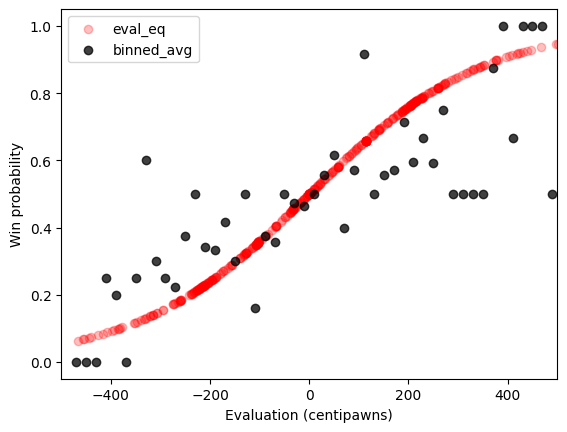

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1️⃣ Filter plies >= 30
search_df_filtered = search_df[search_df['ply'] >= 20].copy()

# 2️⃣ Compute per-game average eval
# Assuming 'game_id' identifies the game
game_avg_eval = search_df_filtered.groupby('game_id')['eval'].transform('mean')

# 3️⃣ Map to result_binary based on game average eval
search_df_filtered['result_binary'] = game_avg_eval.apply(
    lambda x: 0 if x < -300 else 1 if x > 300 else 0.5
)

# 4️⃣ Compute expected win probability from eval
search_df_filtered['win_prob'] = 1 / (1 + 10**(-search_df_filtered['eval'] / 400))

# 5️⃣ Bin evals into 20-point buckets
bin_size = 20
eval_min, eval_max = search_df_filtered['eval'].min(), search_df_filtered['eval'].max()
bins = np.arange(eval_min - (eval_min % bin_size), eval_max + bin_size, bin_size)

search_df_filtered['eval_bin'] = pd.cut(search_df_filtered['eval'], bins=bins)

# 6️⃣ Compute average result_binary per bin
search_dfg = search_df_filtered.groupby('eval_bin')['result_binary'].mean().reset_index()

# 7️⃣ Use bin centers for plotting
search_dfg['eval_center'] = search_dfg['eval_bin'].apply(lambda x: x.left + bin_size / 2)

# 8️⃣ Plot
plt.scatter(search_df_filtered['eval'], search_df_filtered['win_prob'], alpha=0.25, color='red', label='eval_eq')
plt.scatter(search_dfg['eval_center'], search_dfg['result_binary'], alpha=0.75, color='black', label='binned_avg')

plt.xlim(-500, 500)
plt.xlabel('Evaluation (centipawns)')
plt.ylabel('Win probability')
plt.legend()
plt.show()


In [19]:
def stockfish_eval(fen, depth=10):
    stockfish.set_fen_position(fen)

    info = stockfish.get_evaluation()
    # info = {'type': 'cp', 'value': 23} or {'type': 'mate', 'value': 3}

    side_to_move = fen.split()[1]  # 'w' or 'b'

    if info["type"] == "cp":
        value = info["value"]  # centipawns, from White's perspective

        # Flip if Black is to move
        if side_to_move == "b":
            value = -value

        return value

    else:  # mate score
        # Stockfish: positive = White mates, negative = Black mates
        mate_value = 100000 if info["value"] > 0 else -100000

        # Flip to side-to-move perspective
        if side_to_move == "b":
            mate_value = -mate_value

        return mate_value


In [21]:
full_search_df = pd.read_sql_query(
    """
    SELECT sbd.*, s.fen
    FROM searches_by_depth sbd
    JOIN searches s ON sbd.search_id = s.id
    """,
    cnxn
)

full_search_df['sf_eval'] = full_search_df['fen'].apply(stockfish_eval)
full_search_df['elo_diff'] = full_search_df['eval'] - full_search_df['sf_eval']

display(full_search_df)

,search_id,depth,time,eval,move,nodes,q_nodes,tt_stores,tt_hits,fail_highs,fail_lows,ingestion_timestamp,fen,sf_eval,elo_diff
0,1,1,0.1608,25,d2d3,125,31,0,0,0,1,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,17,8
1,1,2,1.3653,34,d2d3,2878,262,3832,0,1932,0,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,22,12
2,1,3,6.2101,17,e2e3,5493,1400,1017,361,2181,815,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,17,0
3,1,4,83.2632,30,d2d3,32935,4399,32,0,1920,26,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,17,13
4,1,5,14.4792,100000,d2d3,1447,3230,1,0,1382,0,2026-01-12 23:18:13,r1bqk1nr/pp1pppbp/2n3p1/2p5/2P5/2N3P1/PP1PPPBP...,14,99986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95299,166,6540,0.0150,0,g1g5,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,100000,-100000
95300,166,6541,0.0150,0,f6e6,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,100000,-100000
95301,166,6542,0.0150,0,g1h1,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,100000,-100000
95302,166,6543,0.0149,0,g1g5,29,0,0,0,0,0,2026-01-12 23:18:13,8/8/5K2/1k6/8/8/8/6Q1 w - - 75 99,100000,-100000


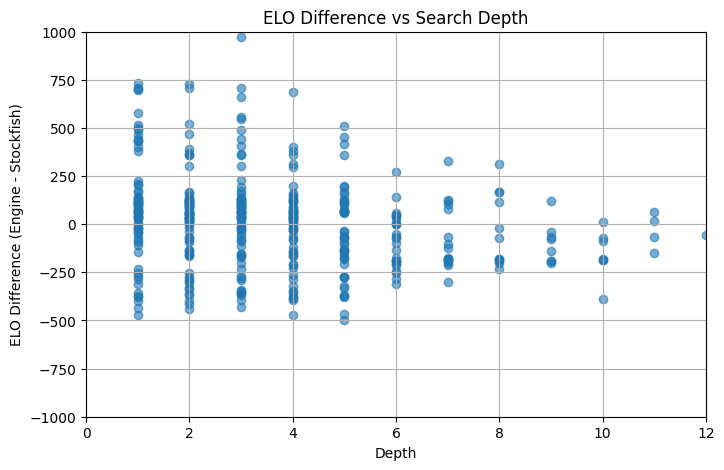

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(full_search_df["depth"], full_search_df["elo_diff"], alpha=0.6)
plt.ylim(-1000,1000)
plt.xlim(0,12)
plt.xlabel("Depth")
plt.ylabel("ELO Difference (Engine - Stockfish)")
plt.title("ELO Difference vs Search Depth")
plt.grid(True)
plt.show()
